In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_excel('/content/US Superstore data.xls')
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

##### Let us understand the attributes of this data set:

'Row ID' - This is nothing but Serial No. <br>
'Order ID' - ID created when a product order is placed. <br>
'Order Date' - Date on which a customer places his/her order. <br>
'Ship Date' - Date on which the order is shipped. <br>
'Ship Mode' - Mode of shipment of each order. <br>
'Customer ID' - ID assigned to each customer who places an order. <br>
'Customer Name' - Name of Customer. <br>
'Segment' - Section from where the order is placed. <br>
'Country' - Country details of this data set. We are looking only for US store data. <br>
'City' - Cities of US are listed here. <br>
'State' - States of US are listed here. <br>
'Postal Code' - pin code <br>
'Region' - grouped into region wise <br>
'Product ID' - Product ID of each product  <br>
'Category' - Category to which each product belongs to.  <br>
'Sub-Category' - Sub-Category of each Category  <br>
'Product Name' - Name of products.  <br>
'Sales' - Selling Price of each product. <br>
'Quantity' - number of quantity available for a particular product. <br>
'Discount' - Discount available on each product. <br>
'Profit' - Profit gained on each product. <br>

#### Vamos a trabajar con los datos que poseen

##### Estraccion de datos tipo fecha como año, mes y dia de la columna 'Order date' el mismo preceso se realizara con 'ship date'

In [7]:
data['year_order'] = data['Order Date'].dt.year
data['month_order'] = data['Order Date'].dt.month
data['day_order'] = data['Order Date'].dt.day

data['year_ship'] = data['Ship Date'].dt.year
data['month_ship'] = data['Ship Date'].dt.month
data['day_ship'] = data['Ship Date'].dt.day

#### Se realiza eñ calculo de total de ventas

In [8]:
data['total_sales'] = (data['Sales'] * data['Quantity']) * (1-data['Discount'])

In [9]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,year_order,month_order,day_order,year_ship,month_ship,day_ship,total_sales
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,2016,11,8,2016,11,11,523.920000
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,2016,11,8,2016,11,11,2195.820000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,2016,6,12,2016,6,16,29.240000
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,2015,10,11,2015,10,18,2633.338125
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,2015,10,11,2015,10,18,35.788800


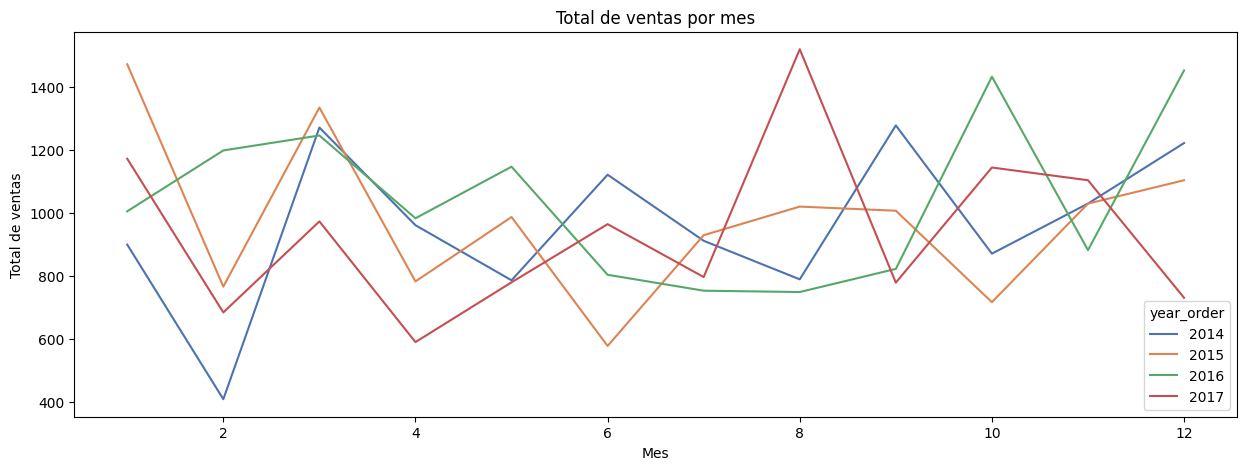

In [10]:
plt.figure(figsize=(15,5))
sns.lineplot(
    data=data,
    x='month_order',
    y='total_sales',
    hue='year_order',
    palette='deep', errorbar=None)
plt.title('Total de ventas por mes')
plt.xlabel('Mes')
plt.ylabel('Total de ventas')

plt.show()

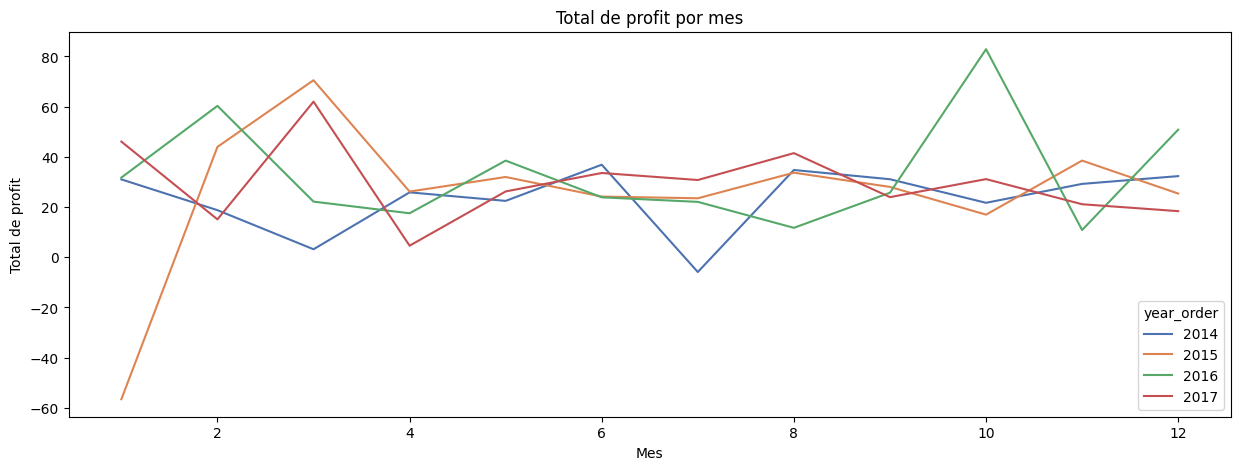

In [11]:
  plt.figure(figsize=(15,5))
sns.lineplot(
    data=data,
    x='month_order',
    y='Profit',
    hue='year_order',
    palette='deep', errorbar=None)
plt.title('Total de profit por mes')
plt.xlabel('Mes')
plt.ylabel('Total de profit')

plt.show()

In [12]:
data.groupby('year_order')['total_sales'].mean()

,total_sales
year_order,
2014,1037.426927
2015,979.272689
2016,1035.826180
2017,932.511640


<Axes: xlabel='year_order'>

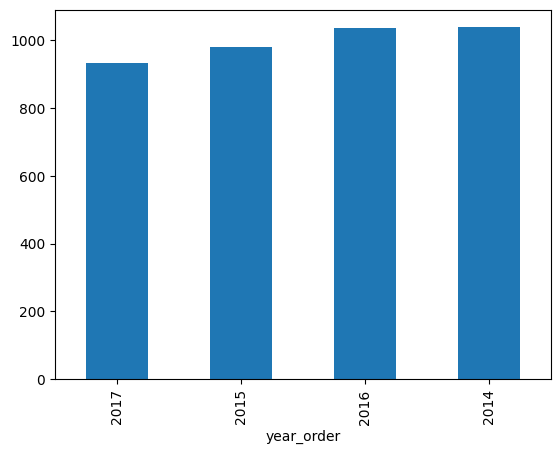

In [ ]:
data.groupby('year_order')['total_sales'].mean().sort_values().plot(kind='bar')

In [13]:
data['Category'].value_counts()

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


In [14]:
data['Sub-Category'].value_counts()

,count
Sub-Category,
Binders,1523
Paper,1370
Furnishings,957
Phones,889
Storage,846
Art,796
Accessories,775
Chairs,617
Appliances,466


<Axes: xlabel='Category'>

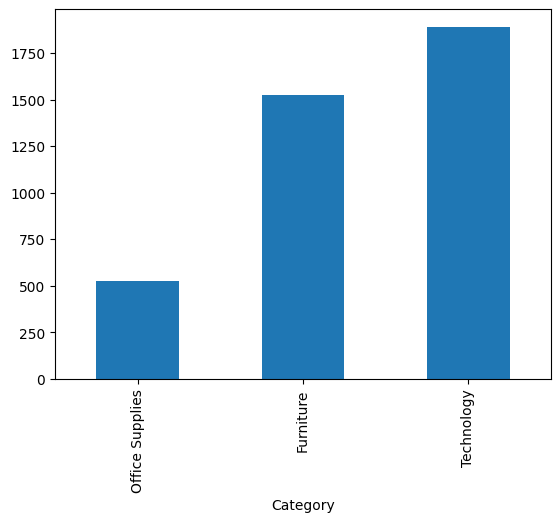

In [15]:
data.groupby('Category')['total_sales'].mean().sort_values().plot(kind='bar')

<Axes: xlabel='Sub-Category'>

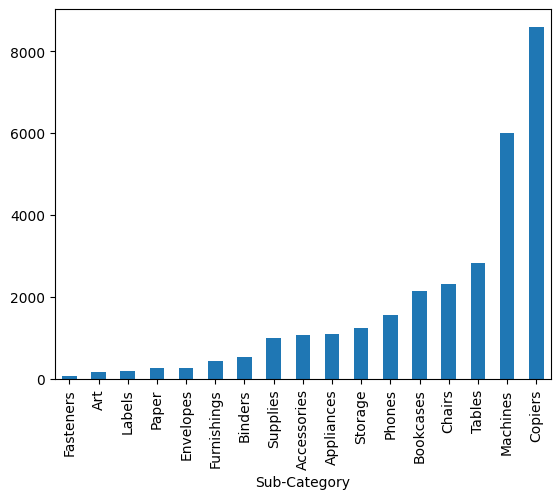

In [16]:
data.groupby('Sub-Category')['total_sales'].mean().sort_values().plot(kind='bar')

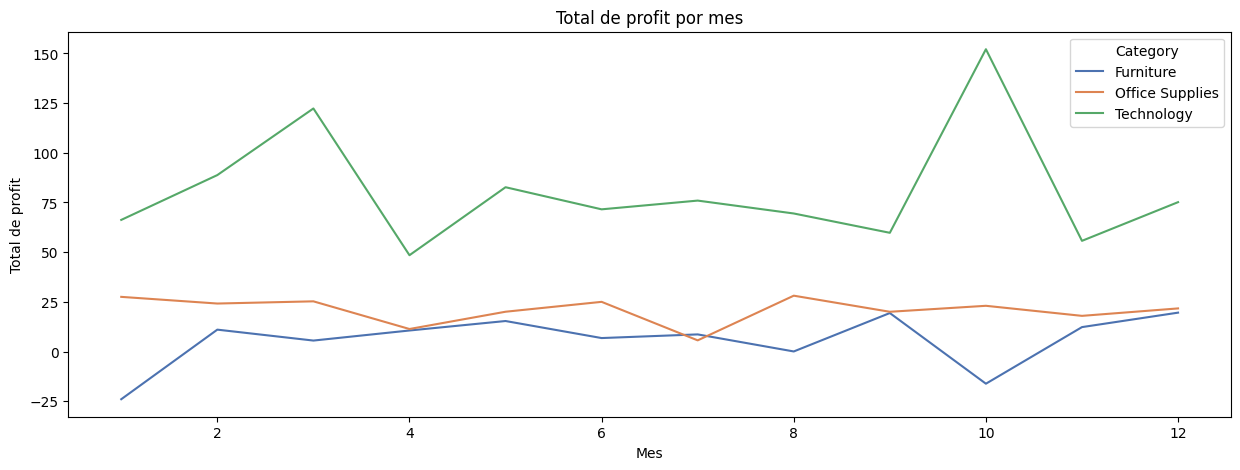

In [17]:
plt.figure(figsize=(15,5))
sns.lineplot(
    data=data,
    x='month_order',
    y='Profit',
    hue='Category',
    palette='deep', errorbar=None)

plt.title('Total de profit por mes')
plt.xlabel('Mes')
plt.ylabel('Total de profit')
plt.show()

In [18]:
data['Tiempor_envio']= (data['Ship Date'] - data['Order Date']).dt.days

In [19]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,year_order,month_order,day_order,year_ship,month_ship,day_ship,total_sales,Tiempor_envio
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,41.9136,2016,11,8,2016,11,11,523.920000,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,219.5820,2016,11,8,2016,11,11,2195.820000,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.00,6.8714,2016,6,12,2016,6,16,29.240000,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.45,-383.0310,2015,10,11,2015,10,18,2633.338125,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.20,2.5164,2015,10,11,2015,10,18,35.788800,7


In [20]:
tiempo_envio_mensual = data.groupby(pd.Grouper(key='Order Date', freq='M'))['Tiempor_envio'].mean().reset_index()
tiempo_envio_mensual['Mes'] = tiempo_envio_mensual['Order Date'].dt.strftime('%Y-%m')
tiempo_envio_mensual.head()

/tmp/ipython-input-302782316.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tiempo_envio_mensual = data.groupby(pd.Grouper(key='Order Date', freq='M'))['Tiempor_envio'].mean().reset_index()


,Order Date,Tiempor_envio,Mes
0,2014-01-31,4.164557,2014-01
1,2014-02-28,4.173913,2014-02
2,2014-03-31,3.974522,2014-03
3,2014-04-30,4.051852,2014-04
4,2014-05-31,3.803279,2014-05


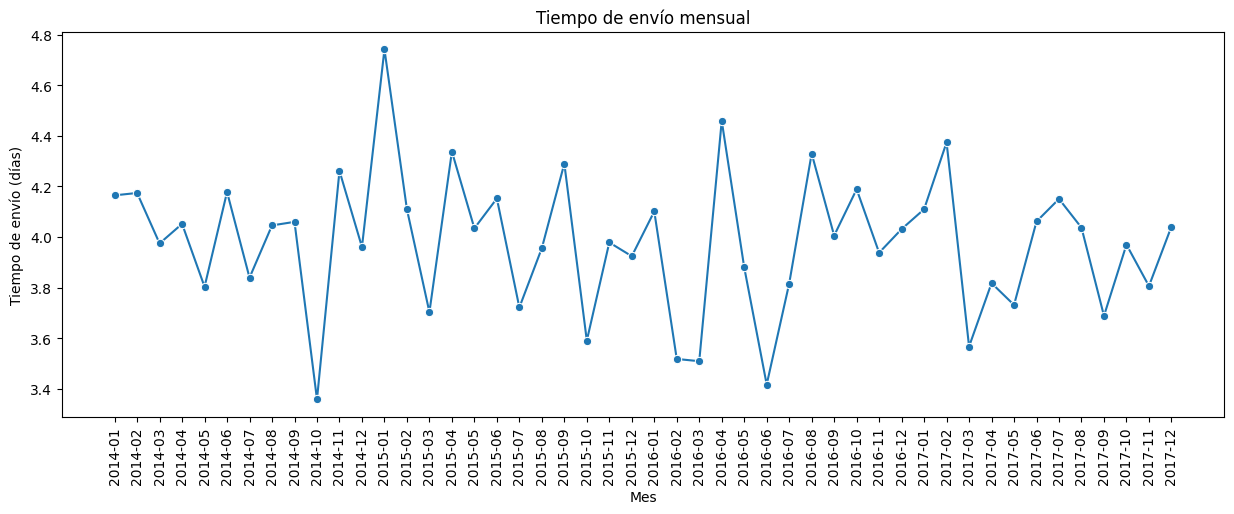

In [21]:
plt.figure(figsize=(15,5))
sns.lineplot(data=tiempo_envio_mensual, x='Mes', y='Tiempor_envio', marker ='o')
plt.xticks(rotation=90)
plt.title('Tiempo de envío mensual')
plt.xlabel('Mes')
plt.ylabel('Tiempo de envío (días)')
plt.show()

In [22]:
tiempo_envio_mensual = data.groupby(pd.Grouper(key='Order Date', freq='M'))['Tiempor_envio'].median().reset_index()
tiempo_envio_mensual['Mes'] = tiempo_envio_mensual['Order Date'].dt.strftime('%Y-%m')
tiempo_envio_mensual.head()

/tmp/ipython-input-2801165847.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tiempo_envio_mensual = data.groupby(pd.Grouper(key='Order Date', freq='M'))['Tiempor_envio'].median().reset_index()


,Order Date,Tiempor_envio,Mes
0,2014-01-31,5.0,2014-01
1,2014-02-28,4.0,2014-02
2,2014-03-31,4.0,2014-03
3,2014-04-30,4.0,2014-04
4,2014-05-31,4.0,2014-05


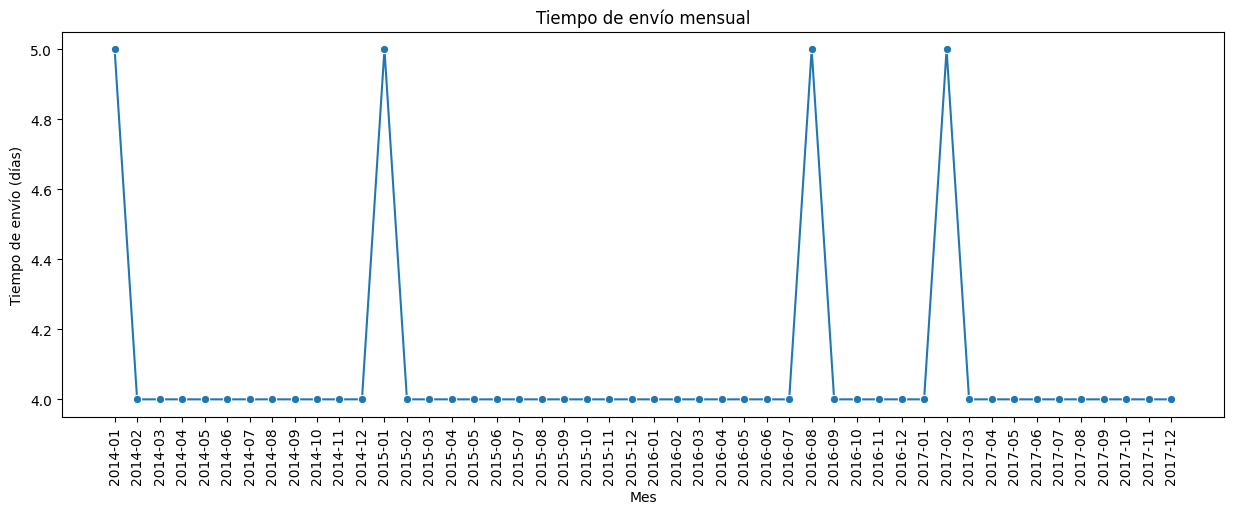

In [23]:
plt.figure(figsize=(15,5))
sns.lineplot(data=tiempo_envio_mensual, x='Mes', y='Tiempor_envio', marker ='o')
plt.xticks(rotation=90)
plt.title('Tiempo de envío mensual')
plt.xlabel('Mes')
plt.ylabel('Tiempo de envío (días)')
plt.show()

####Ciudades donde hay mayor profit hubo

<Axes: xlabel='City'>

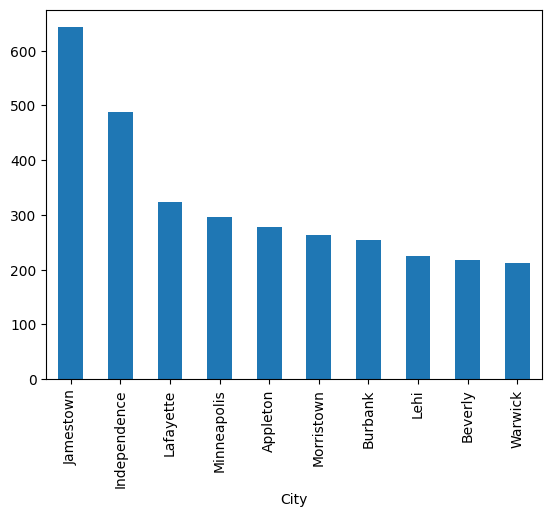

In [24]:
data.groupby('City')['Profit'].mean().sort_values(ascending=False).head(10).plot(kind='bar')

#### Ultima 10 ciudades donde hubo menor profit

<Axes: xlabel='City'>

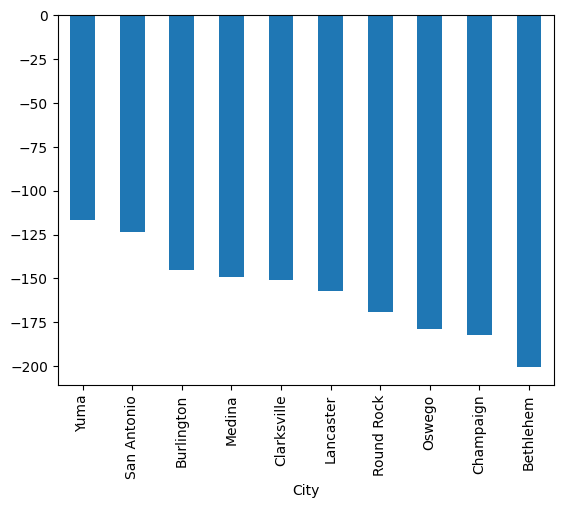

In [25]:
data.groupby('City')['Profit'].mean().sort_values(ascending=False).tail(10).plot(kind='bar')

#### Informacion por trimestre

In [26]:
data['Quarter'] = data['Order Date'].dt.quarter

In [27]:
ventas_trimestrales = data.groupby(['year_order', 'Quarter'])['total_sales'].sum().reset_index()
ventas_trimestrales.head()

,year_order,Quarter,total_sales
0,2014,1,289702.847750
1,2014,2,377424.189382
2,2014,3,594115.575133
3,2014,4,806349.253526
4,2015,1,318803.586316


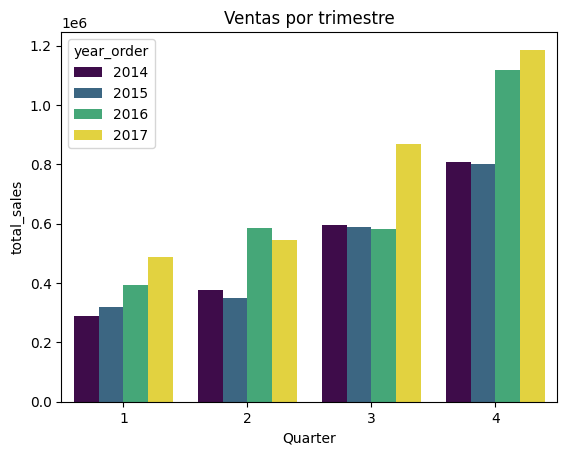

In [29]:
sns.barplot(data=ventas_trimestrales,
            x='Quarter',
            y='total_sales',
            hue='year_order',
            palette= 'viridis')
plt.title('Ventas por trimestre')
plt.show()